In [1]:
import os
from pydantic_ai import Agent
from pydantic_ai.capabilities import MCP
from pydantic_ai.models.openai import OpenAIResponsesModel
from pydantic_ai.providers.openai import OpenAIProvider
from pydantic_ai_harness import FileSystem
from IPython.display import display, Markdown

In [2]:
agent = Agent(
    name="hpc-docs-agent",
    model=OpenAIResponsesModel(
        model_name="@vertexai/gemini-3.7-flash",
        provider=OpenAIProvider(
            base_url="https://ai-gateway.apps.cloud.rt.nyu.edu/v1/",
            api_key=os.getenv("PORTKEY_API_KEY"),
        ),
    ),
    instructions="Be concise and answer questions from retreived knowledge with tools.",
    capabilities=[
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/socrata-mcp/mcp",
            id="socrata-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/flint-mcp/mcp",
            id="flint-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        FileSystem(), # need this to be able to save plots as files in this directory!
    ],
)

In [3]:
result1 = await agent.run("What datasets are available for film shooting in NYC by zip code?") # await is added because the agent is run asynchronously

In [4]:
display(Markdown(result1.output))

On NYC Open Data, the primary and most relevant dataset for film shooting activity by zip code is:

### **1. [Film Permits](https://data.cityofnewyork.us/dataset/tg4x-b46p)**
* **Dataset ID:** `tg4x-b46p`
* **Agency:** Mayor's Office of Media & Entertainment (MOME)
* **Zip Code Field:** `zipcode_s` (contains the zip codes where production activity takes place)
* **Details:** Contains records of approved film, television, theater, commercial, and photo shoot permits asserting exclusive use of city property (streets, sidewalks, parks). Fields include event type, category/subcategory, start/end date and time, borough, community board, police precinct, and parking held locations.

---

### Additional / Related Datasets:
* **[Production office space](https://data.cityofnewyork.us/dataset/bvna-6j7v)** (`bvna-6j7v`): Contains commercial spaces, recording facilities, and sound/film production studios across NYC, searchable by `zip_code`.
* **[Filming Locations (Scenes from the City)](https://data.cityofnewyork.us/dataset/qb3k-n8mm)** (`qb3k-n8mm`): Reference list/file of notable movie and TV filming locations throughout NYC mentioned in the book *Scenes from the City*.

In [5]:
result2 = await agent.run("get the first 10 rows of the film permits dataset", message_history=result1.all_messages())

In [6]:
display(Markdown(result2.output))

Here are the first 10 rows from the **Film Permits** dataset (`tg4x-b46p`):

| Event ID | Event Type | Category | Subcategory | Borough | Zip Code(s) | Start Date/Time | End Date/Time | Parking Held |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **947580** | Theater Load in/Out | Theater | Theater | Manhattan | `10003` | 2026-05-26 12:01 | 2026-05-28 11:59 | EAST 11 ST between 3 AVE & 4 AVE, 3 AVE between EAST 11 ST & EAST 12 ST |
| **947540** | Theater Load in/Out | Theater | Theater | Manhattan | `10003` | 2026-05-24 12:01 | 2026-05-24 23:59 | EAST 11 ST between 3 AVE & 4 AVE, 3 AVE between EAST 11 ST & EAST 12 ST |
| **947283** | Shooting Permit | Television | News | Manhattan | `10036` | 2026-05-22 04:00 | 2026-05-22 10:15 | WEST 47TH ST between 6TH AVE & 7TH AVE |
| **947122** | Theater Load in/Out | Theater | Theater | Manhattan | `10001, 10016, 10018, 10121` | 2026-05-24 12:01 | 2026-05-26 06:00 | WEST 33 ST (7th–9th Ave), WEST 31 ST (5th–8th Ave), 12 AVE (30th–33rd St) |
| **947039** | Shooting Permit | Commercial | Commercial | Manhattan | `10038` | 2026-05-25 07:00 | 2026-05-25 23:00 | BEEKMAN ST between WATER ST & FRONT ST, SOUTH ST between BEEKMAN ST & FULTON ST |
| **947038** | Shooting Permit | Commercial | Commercial | Manhattan | `10038` | 2026-05-24 08:00 | 2026-05-24 22:00 | BEEKMAN ST between WATER ST & FRONT ST, SOUTH ST between BEEKMAN ST & FULTON ST |
| **947034** | Shooting Permit | WEB | Not Applicable | Queens | `11423` | 2026-05-23 11:00 | 2026-05-24 04:00 | 190 STREET between ABERDEEN ROAD & RADNOR ROAD |
| **947030** | Shooting Permit | WEB | Not Applicable | Manhattan | `10009` | 2026-05-22 13:00 | 2026-05-22 22:00 | EAST 3 STREET between 1 AVENUE & AVENUE A |
| **946950** | Shooting Permit | Documentary | Not Applicable | Brooklyn | `11201` | 2026-05-22 06:00 | 2026-05-22 18:00 | MONTAGUE STREET between HICKS ST & CLINTON ST |
| **946911** | Theater Load in/Out | Theater | Theater | Brooklyn | `11201, 11217` | 2026-05-22 07:53 | 2026-05-22 23:59 | ASHLAND PLACE between FULTON STREET & DEKALB AVENUE |

In [7]:
result3 = await agent.run("""generate a plot for that data breaking down permits by borough.
                            Use the New York Times theme and save it to a file named film_permit_plot""", 
                          message_history=result2.all_messages())

In [8]:
display(Markdown(result3.output))

The plot breaking down the first 10 sample film permits by borough has been generated using the **New York Times** (`nyt`) theme and saved to **`film_permit_plot.svg`**.

### Breakdown Summary:
* **Manhattan**: 7 permits (70%)
* **Brooklyn**: 2 permits (20%)
* **Queens**: 1 permit (10%)

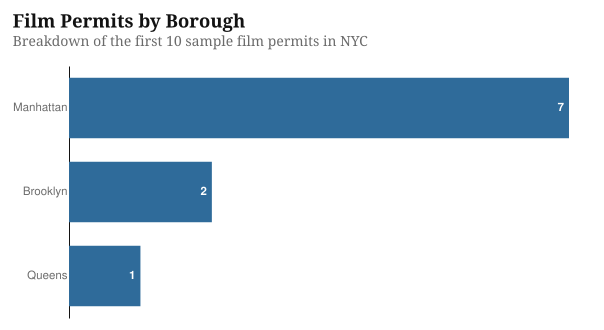

In [9]:
from IPython.display import SVG
SVG(filename='film_permit_plot.svg')